<a href="https://colab.research.google.com/github/busetas/Roketsan_Sensor/blob/main/07_A_Star_Algoritmas%C4%B1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

A* (A-Star) algoritması, otonom araçlarda ve oyun geliştirmede harita üzerinde en kısa ve en optimal yolu bulmak için kullanılan en popüler arama algoritmasıdır.


A* algoritmasını çarpıcı yapan şey, sadece o ana kadar katedilen mesafeye bakmakla kalmayıp, hedefe olan kuş uçuşu mesafeyi (Sezgisellik / Heuristic) tahmin ederek "zeki bir şekilde" hedefe doğru yönelmesidir.

$$\text{Maliyet Fonksiyonu: } f(n) = g(n) + h(n)$$

$g(n)$: Başlangıçtan $n$ noktasına kadar harcanan gerçek maliyet/adım sayısı.

$h(n)$: $n$ noktasından hedefe olan tahmini (Sezgisel / Heuristic) uzaklık (Genellikle Öklid veya Manhattan mesafesi).

**💻 Python Canlı A\* Animasyon Kodu**

Aşağıdaki kod, engellerle dolu bir 2B labirent/harita oluşturur.

A* algoritmasının düğümleri nasıl keşfettiğini (yeşil/sarı alanlar) ve hedefe ulaştığında bulunan optimum yolu (mavi çizgi) adım adım canlı olarak çizdirir.

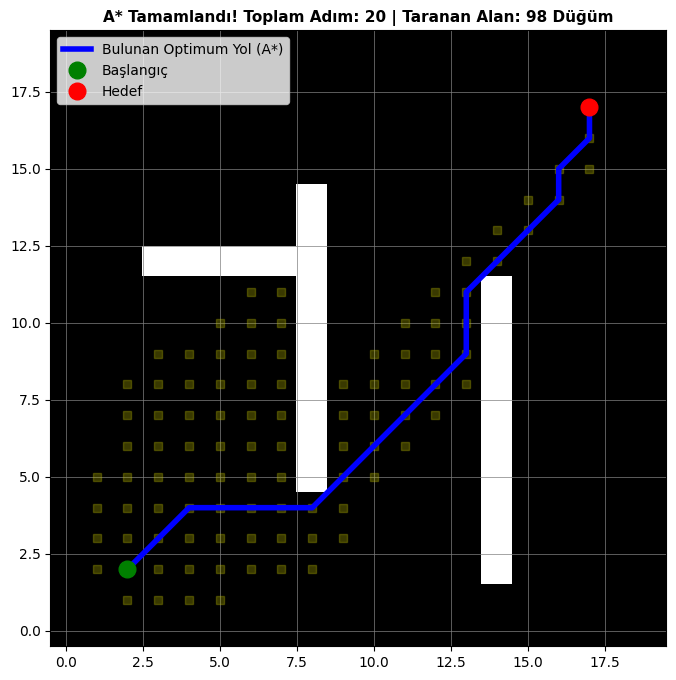

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import heapq
import time

# ==========================================
# 1. A* ALGORİTMASI VE DÜĞÜM TANIMI
# ==========================================
class Node:
    def __init__(self, position, parent=None):
        self.position = position # (x, y)
        self.parent = parent
        self.g = 0 # Başlangıçtan buraya olan maliyet
        self.h = 0 # Hedefe olan sezgisel (heuristic) mesafe
        self.f = 0 # Toplam maliyet (f = g + h)

    def __lt__(self, other):
        return self.f < other.f

def heuristic(pos1, pos2):
    """Euclidean (Öklid) Mesafe Hesabı"""
    return np.sqrt((pos1[0] - pos2[0])**2 + (pos1[1] - pos2[1])**2)

# ==========================================
# 2. HARİTA / ENGEL OLUŞTURMA
# ==========================================
grid_size = 20
grid = np.zeros((grid_size, grid_size))

# Başlangıç ve Bitiş
start_pos = (2, 2)
goal_pos = (17, 17)

# Engeller Ekleme (1: Engel, 0: Boş)
grid[5:15, 8] = 1   # Dikey Duvar
grid[12, 3:9] = 1   # Yatay Duvar
grid[2:12, 14] = 1  # İkinci Dikey Duvar

# ==========================================
# 3. CANLI A* ARAMA DÖNGÜSÜ
# ==========================================
open_list = []
closed_set = set()

start_node = Node(start_pos)
goal_node = Node(goal_pos)

heapq.heappush(open_list, start_node)
open_dict = {start_pos: start_node}

# Görselleştirme Hazırlığı
fig, ax = plt.subplots(figsize=(8, 8))

found = False
current_node = None

# Hareket Seçenekleri (Sağ, Sol, Yukarı, Aşağı ve Çaprazlar)
neighbors = [(0,1), (0,-1), (1,0), (-1,0), (1,1), (1,-1), (-1,1), (-1,-1)]

step_counter = 0

while len(open_list) > 0:
    step_counter += 1
    # f değeri en düşük olan düğümü seç
    current_node = heapq.heappop(open_list)
    current_pos = current_node.position

    if current_pos in open_dict:
        del open_dict[current_pos]

    closed_set.add(current_pos)

    # Hedefe Ulaşıldı mı?
    if current_pos == goal_pos:
        found = True
        break

    # Komşuları Tara
    for dx, dy in neighbors:
        neighbor_pos = (current_pos[0] + dx, current_pos[1] + dy)

        # Harita sınırları kontrolü
        if not (0 <= neighbor_pos[0] < grid_size and 0 <= neighbor_pos[1] < grid_size):
            continue

        # Engel kontrolü
        if grid[neighbor_pos[0], neighbor_pos[1]] == 1:
            continue

        if neighbor_pos in closed_set:
            continue

        # Adım Maliyeti (Çapraz hareketler sqrt(2) ~ 1.41, düz hareketler 1.0)
        move_cost = 1.414 if (dx != 0 and dy != 0) else 1.0
        g_cost = current_node.g + move_cost
        h_cost = heuristic(neighbor_pos, goal_pos)

        # Yeni Komşu Düğüm
        if neighbor_pos not in open_dict or g_cost < open_dict[neighbor_pos].g:
            neighbor_node = Node(neighbor_pos, current_node)
            neighbor_node.g = g_cost
            neighbor_node.h = h_cost
            neighbor_node.f = g_cost + h_cost

            heapq.heappush(open_list, neighbor_node)
            open_dict[neighbor_pos] = neighbor_node

    # --- CANLI GÖRSELLEŞTİRME (Her 3 Adımda Bir) ---
    if step_counter % 3 == 0:
        ax.clear()

        # Haritayı Çiz
        display_grid = np.copy(grid)

        # Keşfedilen (Closed) alanları sarı yap
        for pos in closed_set:
            display_grid[pos[0], pos[1]] = 0.3

        # Sırada Bekleyen (Open) alanları yeşil yap
        for pos in open_dict:
            display_grid[pos[0], pos[1]] = 0.6

        ax.imshow(display_grid, cmap='binary_r', origin='lower')

        # Geçici Rotayı Çiz (Anlık Yol)
        temp_path = []
        curr = current_node
        while curr:
            temp_path.append(curr.position)
            curr = curr.parent
        if len(temp_path) > 0:
            tp = np.array(temp_path)
            ax.plot(tp[:, 1], tp[:, 0], 'r--', linewidth=1.5, label='Anlık Arama Yolu')

        # Başlangıç ve Bitiş İşaretleri
        ax.plot(start_pos[1], start_pos[0], 'go', markersize=12, label='Başlangıç (Start)')
        ax.plot(goal_pos[1], goal_pos[0], 'ro', markersize=12, label='Hedef (Goal)')

        ax.set_title(f"A* Algoritması Adım Adım Yol Arama — Adım: {step_counter}", fontsize=11)
        ax.set_xticks(range(grid_size))
        ax.set_yticks(range(grid_size))
        ax.grid(True, color='gray', linestyle='-', linewidth=0.5)
        ax.legend(loc='upper left')

        clear_output(wait=True)
        display(fig)
        time.sleep(0.01)

# ==========================================
# 4. SONUÇ: OPTİMUM YOLUN ÇİZİMİ
# ==========================================
if found:
    path = []
    curr = current_node
    while curr:
        path.append(curr.position)
        curr = curr.parent
    path = path[::-1] # Başlangıçtan sona sırala

    ax.clear()
    ax.imshow(grid, cmap='binary_r', origin='lower')

    # Tüm aranan alanları hafif renklendir
    for pos in closed_set:
        ax.plot(pos[1], pos[0], 'ys', alpha=0.3)

    p = np.array(path)
    ax.plot(p[:, 1], p[:, 0], 'b-', linewidth=4, label='Bulunan Optimum Yol (A*)')
    ax.plot(start_pos[1], start_pos[0], 'go', markersize=12, label='Başlangıç')
    ax.plot(goal_pos[1], goal_pos[0], 'ro', markersize=12, label='Hedef')

    ax.set_title(f"A* Tamamlandı! Toplam Adım: {len(path)} | Taranan Alan: {len(closed_set)} Düğüm", fontsize=11, fontweight='bold')
    ax.grid(True, color='gray', linestyle='-', linewidth=0.5)
    ax.legend(loc='upper left')

    clear_output(wait=True)
    display(fig)

plt.close(fig)

Kodu Her Çalıştırmada Rastgele Engeller Üretecek Hale Getirelim 🎲

Kodu daha heyecanlı hale getirmek için engelleri, başlangıç ve bitiş noktalarını her çalıştırmada rastgele üretebiliriz.

Aşağıdaki değişim ile haritanın belirli bir yüzdesini (örneğin %25'ini) rastgele engellerle doldurabiliriz.

In [3]:
# ==========================================
# HARİTA / RASTGELE ENGEL OLUŞTURMA
# ==========================================
grid_size = 20
grid = np.zeros((grid_size, grid_size))

# Başlangıç ve Bitiş Noktaları
start_pos = (0, 0)
goal_pos = (grid_size - 1, grid_size - 1)

# Haritanın %25'ine Rastgele Engeller Koy (Nokta engeller ve Bloklar)
obstacle_density = 0.25
num_obstacles = int(grid_size * grid_size * obstacle_density)

for _ in range(num_obstacles):
    rx = np.random.randint(0, grid_size)
    ry = np.random.randint(0, grid_size)

    # Başlangıç ve bitiş noktasına engel koyma!
    if (rx, ry) != start_pos and (rx, ry) != goal_pos:
        grid[rx, ry] = 1

Bu değişikliği eklediğimizde, kodu her çalıştırdığımızda A* algoritması farklı bir labirent düzeninde hedefe giden yolu arayacak ve engellerin durumuna göre tamamen farklı rotalar çizecektir.

-------------------------------
Aşağıda, her çalıştırdığımızda haritadaki engelleri, başlangıç ve bitiş noktalarını tamamen rastgele oluşturan güncellenmiş canlı A* kodu yer almaktadır.

Rastgele harita üretildikten sonra algoritmanın kilitlenip kalmaması için, başlangıçtan bitişe geçerli bir yol olup olmadığı mantıksal olarak kontrol edilir ve çözülebilir bir harita bulunana kadar otomatik yeni harita üretilir.

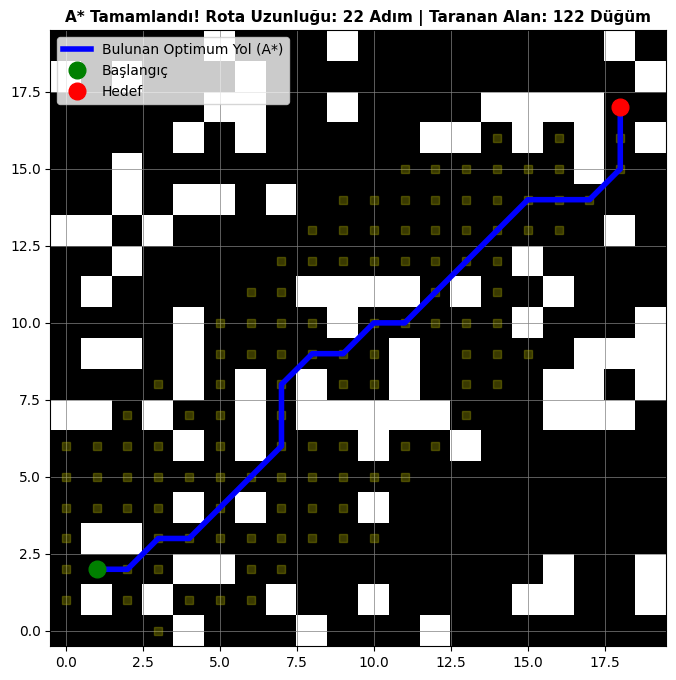

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import heapq
import time

# ==========================================
# 1. A* ALGORİTMASI VE DÜĞÜM TANIMI
# ==========================================
class Node:
    def __init__(self, position, parent=None):
        self.position = position # (x, y)
        self.parent = parent
        self.g = 0 # Başlangıçtan buraya olan maliyet
        self.h = 0 # Hedefe olan sezgisel (heuristic) mesafe
        self.f = 0 # Toplam maliyet (f = g + h)

    def __lt__(self, other):
        return self.f < other.f

def heuristic(pos1, pos2):
    """Euclidean (Öklid) Mesafe Hesabı"""
    return np.sqrt((pos1[0] - pos2[0])**2 + (pos1[1] - pos2[1])**2)

# ==========================================
# 2. RASTGELE VE ÇÖZÜLEBİLİR HARİTA ÜRETİCİ
# ==========================================
grid_size = 20
obstacle_density = 0.28  # Haritanın %28'i rastgele engel

def generate_random_grid(size, density):
    grid = np.zeros((size, size))

    # Rastgele Başlangıç ve Bitiş
    start = (np.random.randint(0, 3), np.random.randint(0, 3))
    goal = (np.random.randint(size-3, size), np.random.randint(size-3, size))

    # Engelleri Dağıt
    num_obstacles = int(size * size * density)
    for _ in range(num_obstacles):
        rx, ry = np.random.randint(0, size), np.random.randint(0, size)
        if (rx, ry) != start and (rx, ry) != goal:
            grid[rx, ry] = 1

    return grid, start, goal

# Geçerli bir yol olana kadar rastgele harita dene
while True:
    grid, start_pos, goal_pos = generate_random_grid(grid_size, obstacle_density)

    # Ön kontrol (A* çalıştırmadan yol var mı bakıyoruz)
    temp_open = [start_pos]
    temp_visited = {start_pos}
    has_path = False

    while temp_open:
        curr = temp_open.pop(0)
        if curr == goal_pos:
            has_path = True
            break
        for dx, dy in [(0,1),(0,-1),(1,0),(-1,0),(1,1),(1,-1),(-1,1),(-1,-1)]:
            nx, ny = curr[0]+dx, curr[1]+dy
            if 0 <= nx < grid_size and 0 <= ny < grid_size and grid[nx, ny] == 0 and (nx, ny) not in temp_visited:
                temp_visited.add((nx, ny))
                temp_open.append((nx, ny))

    if has_path:
        break  # Çözülebilir harita bulundu!

# ==========================================
# 3. CANLI A* ARAMA DÖNGÜSÜ
# ==========================================
open_list = []
closed_set = set()

start_node = Node(start_pos)
goal_node = Node(goal_pos)

heapq.heappush(open_list, start_node)
open_dict = {start_pos: start_node}

fig, ax = plt.subplots(figsize=(8, 8))

neighbors = [(0,1), (0,-1), (1,0), (-1,0), (1,1), (1,-1), (-1,1), (-1,-1)]
step_counter = 0
current_node = None
found = False

while len(open_list) > 0:
    step_counter += 1
    current_node = heapq.heappop(open_list)
    current_pos = current_node.position

    if current_pos in open_dict:
        del open_dict[current_pos]

    closed_set.add(current_pos)

    if current_pos == goal_pos:
        found = True
        break

    for dx, dy in neighbors:
        neighbor_pos = (current_pos[0] + dx, current_pos[1] + dy)

        if not (0 <= neighbor_pos[0] < grid_size and 0 <= neighbor_pos[1] < grid_size):
            continue
        if grid[neighbor_pos[0], neighbor_pos[1]] == 1:
            continue
        if neighbor_pos in closed_set:
            continue

        move_cost = 1.414 if (dx != 0 and dy != 0) else 1.0
        g_cost = current_node.g + move_cost
        h_cost = heuristic(neighbor_pos, goal_pos)

        if neighbor_pos not in open_dict or g_cost < open_dict[neighbor_pos].g:
            neighbor_node = Node(neighbor_pos, current_node)
            neighbor_node.g = g_cost
            neighbor_node.h = h_cost
            neighbor_node.f = g_cost + h_cost

            heapq.heappush(open_list, neighbor_node)
            open_dict[neighbor_pos] = neighbor_node

    # --- CANLI GÖRSELLEŞTİRME ---
    if step_counter % 3 == 0:
        ax.clear()
        display_grid = np.copy(grid)

        for pos in closed_set:
            display_grid[pos[0], pos[1]] = 0.3
        for pos in open_dict:
            display_grid[pos[0], pos[1]] = 0.6

        ax.imshow(display_grid, cmap='binary_r', origin='lower')

        # Anlık arama rotası
        temp_path = []
        curr = current_node
        while curr:
            temp_path.append(curr.position)
            curr = curr.parent
        if len(temp_path) > 0:
            tp = np.array(temp_path)
            ax.plot(tp[:, 1], tp[:, 0], 'r--', linewidth=1.5, label='Anlık Arama Yolu')

        ax.plot(start_pos[1], start_pos[0], 'go', markersize=12, label='Başlangıç (Start)')
        ax.plot(goal_pos[1], goal_pos[0], 'ro', markersize=12, label='Hedef (Goal)')

        ax.set_title(f"A* Rastgele Harita Simülasyonu — Adım: {step_counter}", fontsize=11)
        ax.set_xticks(range(grid_size))
        ax.set_yticks(range(grid_size))
        ax.grid(True, color='gray', linestyle='-', linewidth=0.5)
        ax.legend(loc='upper left')

        clear_output(wait=True)
        display(fig)
        time.sleep(0.01)

# ==========================================
# 4. SONUÇ: OPTİMUM YOLUN ÇİZİMİ
# ==========================================
if found:
    path = []
    curr = current_node
    while curr:
        path.append(curr.position)
        curr = curr.parent
    path = path[::-1]

    ax.clear()
    ax.imshow(grid, cmap='binary_r', origin='lower')

    for pos in closed_set:
        ax.plot(pos[1], pos[0], 'ys', alpha=0.3)

    p = np.array(path)
    ax.plot(p[:, 1], p[:, 0], 'b-', linewidth=4, label='Bulunan Optimum Yol (A*)')
    ax.plot(start_pos[1], start_pos[0], 'go', markersize=12, label='Başlangıç')
    ax.plot(goal_pos[1], goal_pos[0], 'ro', markersize=12, label='Hedef')

    ax.set_title(f"A* Tamamlandı! Rota Uzunluğu: {len(path)} Adım | Taranan Alan: {len(closed_set)} Düğüm", fontsize=11, fontweight='bold')
    ax.grid(True, color='gray', linestyle='-', linewidth=0.5)
    ax.legend(loc='upper left')

    clear_output(wait=True)
    display(fig)

plt.close(fig)